# Plotting Kendrick plots 

> Can't wait to make our first Kendrick plot!

In [ ]:
#|default_exp kendrick_plot

In [ ]:
#|hide 
from fairdatanow import DataViewer, login, filters

In [ ]:
#|hide 
url = 'https://laboppad.nl/asap-data'
dv = DataViewer(login(url), **filters(search='joana_100-24-1', extensions=['.raw']))
raw_file = dv.download_filtered()[0]

Connection with nextcloud server is ok.
Ready with downloading 1 selected remote files to local cache: /home/frank/.cache/fairdatanow                                                                      


Let's see if we can now explore the mass spectral data in our cached raw file. However, before creating a Kendrick plot let's take a look at the (centroided and time integrated) positive and negative mode mass spectra. This can be done conveniently with a bit of matplotlib code. 

In [ ]:
from kendrick import read_raw, centralize 
import matplotlib.pyplot as plt
import os 
import numpy as np 

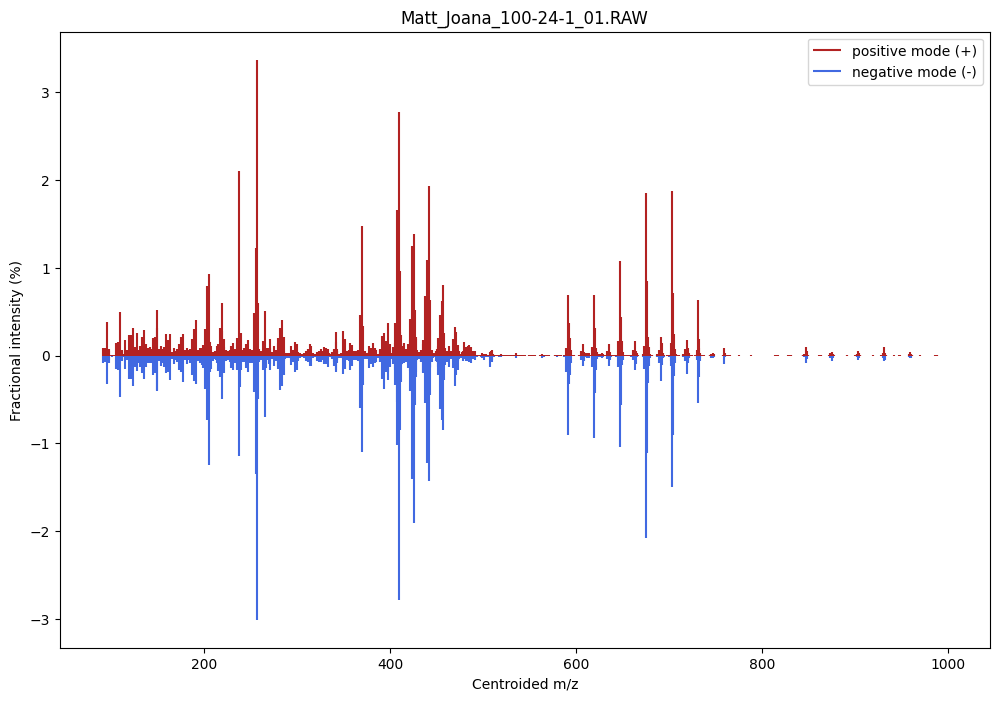

In [ ]:
#|code-fold: true 
raw_file = '/home/frank/.cache/fairdatanow/asap-data/2025 Théo-Fany Lange - the dutch method/xcalibur raw data files/Matt_Joana_100-24-1_01.RAW'

df_pos, df_neg = read_raw(raw_file) 
df_total_pos = centralize(df_pos)
df_total_neg = centralize(df_neg)

fig, ax =plt.subplots(figsize=[12, 8])

xlabel, ylabel = df_total_pos.columns
x_pos, y_pos = df_total_pos.values.T
x_neg, y_neg = df_total_neg.values.T
title = f'{os.path.basename(raw_file)}'

ax.vlines(x_pos, np.zeros_like(y_pos), y_pos, color='firebrick', label='positive mode (+)')
ax.vlines(x_neg, -y_neg, np.zeros_like(y_neg), color='royalblue', label='negative mode (-)')
ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel) 
ax.set_title(title)
ax.legend();

Kendrick plots are simply another representation of the same data. From the centroided m/z values we can compute the Kendrick mass and the Kendrick mass defect with the `compute_kendrick_mass_and_defect()` function. 

In [ ]:
from kendrick import compute_kendrick_mass_and_defect

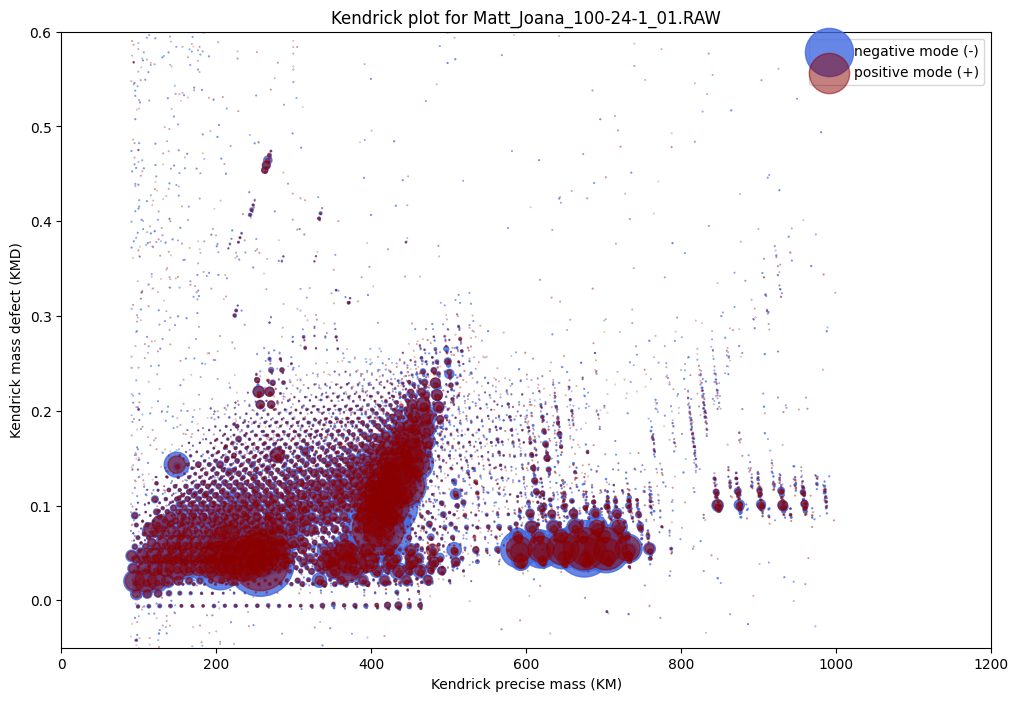

In [ ]:
#|code-fold: true  

mz_pos = df_total_pos['Centroided m/z'].values 
inty_pos = df_total_pos['Fractional intensity (%)']
km_pos, kmd_pos = compute_kendrick_mass_and_defect(mz_pos) 

mz_neg = df_total_neg['Centroided m/z'].values 
inty_neg = df_total_neg['Fractional intensity (%)']
km_neg, kmd_neg = compute_kendrick_mass_and_defect(mz_neg) 

fig, ax = plt.subplots(figsize=[12, 8]) 
thres_pos = 0.0001
s_pos = 500

thres_neg = 0.0001
s_neg = 800

ax.set_ylim([-0.05, 0.6])
ax.set_xlim([0, 1200])
ax.scatter(km_neg[inty_neg > thres_neg], kmd_neg[inty_neg > thres_neg], s=s_neg*inty_neg[inty_neg > thres_neg], alpha=0.8, color='royalblue', label='negative mode (-)')
ax.scatter(km_pos[inty_pos > thres_pos], kmd_pos[inty_pos > thres_pos], s=s_pos*inty_pos[inty_pos > thres_pos], alpha=0.5, color='darkred', label='positive mode (+)')

ax.set_xlabel('Kendrick precise mass (KM)')
ax.set_ylabel('Kendrick mass defect (KMD)')
ax.set_title(f'Kendrick plot for {os.path.basename(raw_file)}')
ax.legend();

This Kendrick plot looks somewhat similar to the excel version by Wim. We need to figure out the reasons for these differences...

## Functions 

In [ ]:
#|export 

from kendrick import read_raw, centralize 
from molmass import Formula 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import os

In [ ]:
#|export 

def compute_kendrick_mass_and_defect(mz, monomer='CH2', offset=0.6): 
    '''Compute Kendrick precise mass for array `mz`. 
    
    Default `monomer` is 'CH2'. 
    
    It is not clear to me why the offset by Wim is chosen 0.6. 
    
    Reurns: km, kmd 
    ''' 

    # kendrick precise mass 
    mono_mass = Formula(monomer).monoisotopic_mass 
    km = mz * round(mono_mass) / mono_mass 

    # kendrick nominal mass 
    knm = (km + offset).astype(int)

    # kendrick mass defect
    kmd = knm - km 
    
    return km, kmd

    